# H4 전용 EDA — transaction_data 상세 확인

H4/H4-1/H4-2에서 실제로 쓰는 컬럼(household_key, DAY, WEEK_NO, BASKET_ID, SALES_VALUE)을 중심으로,
지난번 8개 테이블 개괄 노트북보다 한 단계 더 깊게 본다.

**목적**
1. 모양(shape)·타입·중복행 확인
2. 결측치 확인
3. SALES_VALUE 분포 (이상치, 음수값 등 H4 계산에 영향 줄 수 있는 것들)
4. household_key 단위 집계 시 주의할 점 (한 가구당 관측치 편차 등)
5. 안정구간(week 16~99) 필터링 후 재확인


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic"]
available = {f.name for f in fm.fontManager.ttflist}
font_name = next((c for c in candidates if c in available), None)
if font_name:
    plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)

DATA_DIR = "data/"
tx = pd.read_csv(DATA_DIR + "transaction_data.csv")
print("shape:", tx.shape)
tx.head()


shape: (2595732, 12)


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0


## 1. 기본 구조 확인

- dtypes, 메모리 사용량
- 완전 중복행 존재 여부 (같은 거래가 두 번 로드된 경우 SALES_VALUE 합산이 두 배로 뻥튀기될 수 있음)
- H4에서 쓸 컬럼만 따로 추려서 이후 작업


In [2]:
print("--- dtypes ---")
print(tx.dtypes)

print(f"\n메모리 사용량: {tx.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

n_dup = tx.duplicated().sum()
print(f"\n완전 중복행 수: {n_dup:,} ({n_dup/len(tx)*100:.3f}%)")
if n_dup > 0:
    print("⚠ 중복행 존재 — H4 집계 전 제거 필요 여부 검토")

# H4에서 쓸 핵심 컬럼
h4_cols = ["household_key", "BASKET_ID", "DAY", "WEEK_NO", "SALES_VALUE"]
print("\n핵심 컬럼 결측치")
print(tx[h4_cols].isna().sum())


--- dtypes ---
household_key          int64
BASKET_ID              int64
DAY                    int64
PRODUCT_ID             int64
QUANTITY               int64
SALES_VALUE          float64
STORE_ID               int64
RETAIL_DISC          float64
TRANS_TIME             int64
WEEK_NO                int64
COUPON_DISC          float64
COUPON_MATCH_DISC    float64
dtype: object

메모리 사용량: 237.6 MB

완전 중복행 수: 0 (0.000%)

핵심 컬럼 결측치
household_key    0
BASKET_ID        0
DAY              0
WEEK_NO          0
SALES_VALUE      0
dtype: int64


## 2. household_key, BASKET_ID 기본 통계

- 전체 고유 가구 수, 고유 basket 수
- 가구당 관측치(row) 수 분포 — 극단적으로 적거나 많은 가구가 있는지 (H4 랭킹 계산 시 왜곡 요인)


고유 household_key 수: 2,500
고유 BASKET_ID 수: 276,484
WEEK_NO 범위: 1 ~ 102
DAY 범위: 1 ~ 711

가구당 거래 row 수 분포
count    2500.000000
mean     1038.292800
std       999.097354
min         4.000000
25%       325.000000
50%       734.000000
75%      1454.500000
max      6851.000000
dtype: float64


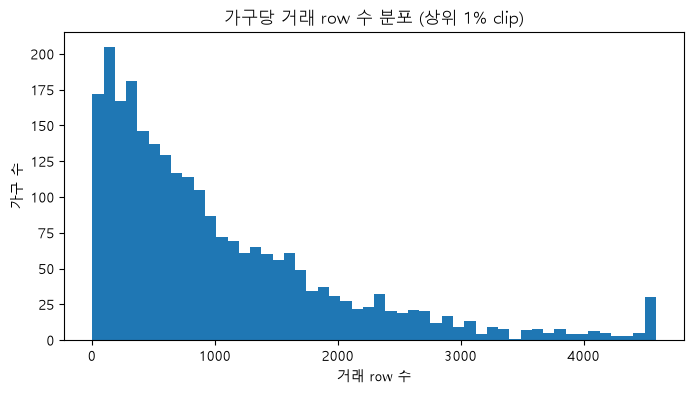


거래 row 수 하위 1% 가구 (극단적으로 적은 활동): 25개


In [3]:
print(f"고유 household_key 수: {tx['household_key'].nunique():,}")
print(f"고유 BASKET_ID 수: {tx['BASKET_ID'].nunique():,}")
print(f"WEEK_NO 범위: {tx['WEEK_NO'].min()} ~ {tx['WEEK_NO'].max()}")
print(f"DAY 범위: {tx['DAY'].min()} ~ {tx['DAY'].max()}")

rows_per_hh = tx.groupby("household_key").size()
print("\n가구당 거래 row 수 분포")
print(rows_per_hh.describe())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rows_per_hh.clip(upper=rows_per_hh.quantile(0.99)), bins=50)
ax.set_title("가구당 거래 row 수 분포 (상위 1% clip)")
ax.set_xlabel("거래 row 수")
ax.set_ylabel("가구 수")
plt.show()

print(f"\n거래 row 수 하위 1% 가구 (극단적으로 적은 활동): {(rows_per_hh <= rows_per_hh.quantile(0.01)).sum()}개")


## 3. SALES_VALUE 분포 및 이상치

H4 계산의 핵심 컬럼이라 가장 꼼꼼히 봐야 함.
- 음수값(환불 추정) 비율
- 0값 비율
- 극단값(상위 outlier) 존재 여부 — IQR 기준


SALES_VALUE 요약 통계
count    2.595732e+06
mean     3.104120e+00
std      4.182274e+00
min      0.000000e+00
25%      1.290000e+00
50%      2.000000e+00
75%      3.490000e+00
max      8.400000e+02
Name: SALES_VALUE, dtype: float64

음수 SALES_VALUE 건수: 0 (0.000%)
0 SALES_VALUE 건수: 18,850 (0.726%)

IQR 기준 상단 이상치 (> 6.79): 190,644건 (7.34%)
최댓값: 840.00


C:\Users\spide\AppData\Local\Temp\ipykernel_7972\532394962.py:20: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(tx["SALES_VALUE"], vert=True)


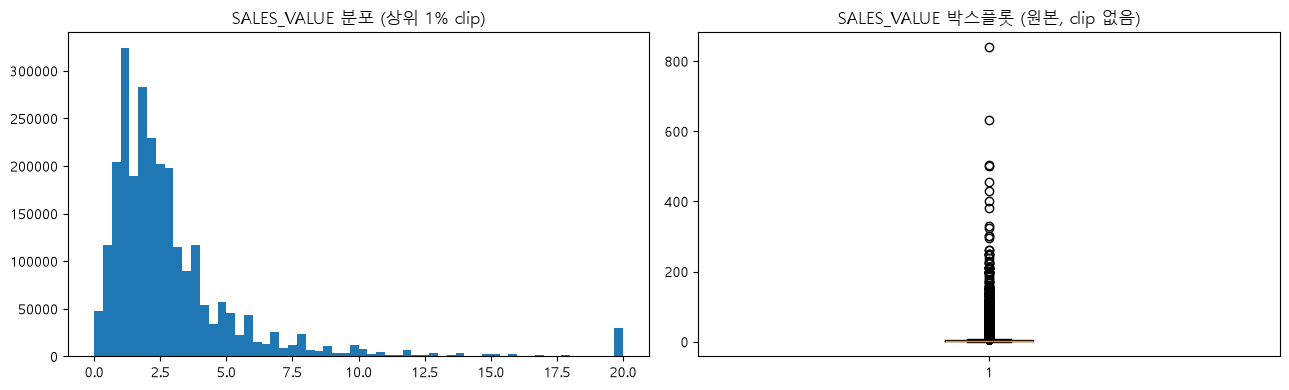

In [4]:
print("SALES_VALUE 요약 통계")
print(tx["SALES_VALUE"].describe())

n_negative = (tx["SALES_VALUE"] < 0).sum()
n_zero = (tx["SALES_VALUE"] == 0).sum()
print(f"\n음수 SALES_VALUE 건수: {n_negative:,} ({n_negative/len(tx)*100:.3f}%)")
print(f"0 SALES_VALUE 건수: {n_zero:,} ({n_zero/len(tx)*100:.3f}%)")

# IQR 기준 이상치
q1, q3 = tx["SALES_VALUE"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
n_outlier = (tx["SALES_VALUE"] > upper_bound).sum()
print(f"\nIQR 기준 상단 이상치 (> {upper_bound:.2f}): {n_outlier:,}건 ({n_outlier/len(tx)*100:.2f}%)")
print(f"최댓값: {tx['SALES_VALUE'].max():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(tx["SALES_VALUE"].clip(upper=tx["SALES_VALUE"].quantile(0.99)), bins=60)
axes[0].set_title("SALES_VALUE 분포 (상위 1% clip)")
axes[1].boxplot(tx["SALES_VALUE"], vert=True)
axes[1].set_title("SALES_VALUE 박스플롯 (원본, clip 없음)")
plt.tight_layout()
plt.show()


In [5]:
# 음수값이 있다면 실제로 어떤 모습인지 확인
if n_negative > 0:
    print("음수 SALES_VALUE 샘플")
    display(tx[tx["SALES_VALUE"] < 0].head(10))


## 4. 가구별 총 SALES_VALUE(전체 기간) 분포

H4가 결국 "가구별 총 지출액 순위"를 다루는 만큼, 집계 후 분포도 미리 확인.
극단적으로 튀는 소수 가구(대량구매/이상거래)가 순위를 왜곡하지 않는지 체크.


가구별 총 SALES_VALUE(전체 기간) 요약
count     2500.000000
mean      3222.985232
std       3349.026076
min          8.170000
25%        970.740000
50%       2157.750000
75%       4413.320000
max      38319.790000
Name: SALES_VALUE, dtype: float64


C:\Users\spide\AppData\Local\Temp\ipykernel_7972\1658776140.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(hh_total_sales, vert=True)


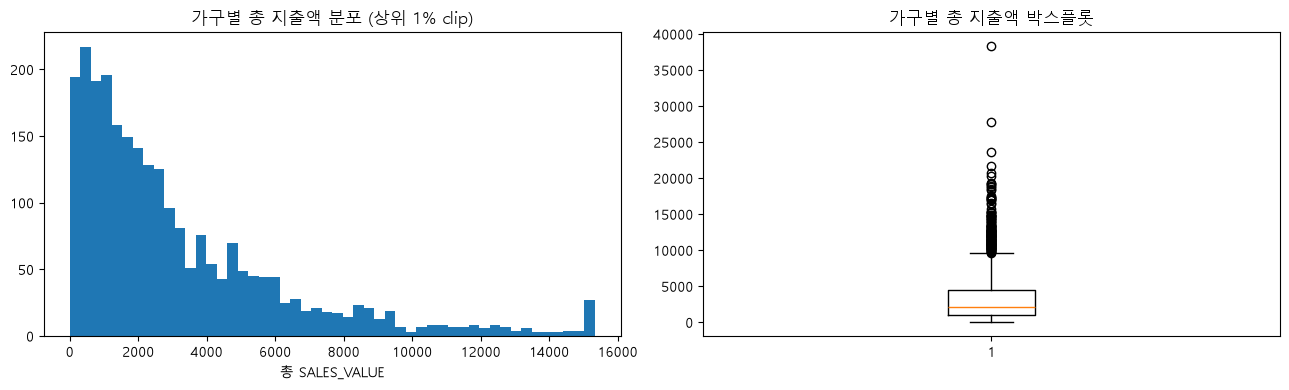


총 지출액 상위 5개 가구
household_key
1023    38319.79
1609    27859.68
2322    23646.92
1453    21661.29
2459    20671.50
Name: SALES_VALUE, dtype: float64

총 지출액 하위 5개 가구 (활동 매우 적은 가구)
household_key
522     29.34
689     28.96
2201    27.51
1897    19.58
494      8.17
Name: SALES_VALUE, dtype: float64


In [6]:
hh_total_sales = tx.groupby("household_key")["SALES_VALUE"].sum().sort_values(ascending=False)

print("가구별 총 SALES_VALUE(전체 기간) 요약")
print(hh_total_sales.describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(hh_total_sales.clip(upper=hh_total_sales.quantile(0.99)), bins=50)
axes[0].set_title("가구별 총 지출액 분포 (상위 1% clip)")
axes[0].set_xlabel("총 SALES_VALUE")

axes[1].boxplot(hh_total_sales, vert=True)
axes[1].set_title("가구별 총 지출액 박스플롯")
plt.tight_layout()
plt.show()

print("\n총 지출액 상위 5개 가구")
print(hh_total_sales.head())
print("\n총 지출액 하위 5개 가구 (활동 매우 적은 가구)")
print(hh_total_sales.tail())


## 5. 안정구간(WEEK_NO 17~99)만 필터링 후 재확인

지난번 결정한 대로, 온보딩(1~16주)·절단(100~102주) 구간을 제외하고
동일한 확인을 다시 해서 필터링 전후 차이를 본다.


In [9]:
tx_stable = tx[(tx["WEEK_NO"] >= 17) & (tx["WEEK_NO"] <= 99)].copy()

print(f"필터링 전: {len(tx):,}행, 가구 {tx['household_key'].nunique():,}개")
print(f"필터링 후(안정구간): {len(tx_stable):,}행, 가구 {tx_stable['household_key'].nunique():,}개")
print(f"제외된 행 비율: {(1 - len(tx_stable)/len(tx))*100:.1f}%")

hh_total_sales_stable = tx_stable.groupby("household_key")["SALES_VALUE"].sum().sort_values(ascending=False)
print("\n안정구간 기준 가구별 총 지출액 요약")
print(hh_total_sales_stable.describe())


필터링 전: 2,595,732행, 가구 2,500개
필터링 후(안정구간): 2,317,271행, 가구 2,492개
제외된 행 비율: 10.7%

안정구간 기준 가구별 총 지출액 요약
count     2492.000000
mean      2892.329165
std       3077.855256
min          4.490000
25%        820.977500
50%       1905.725000
75%       3989.860000
max      36836.490000
Name: SALES_VALUE, dtype: float64


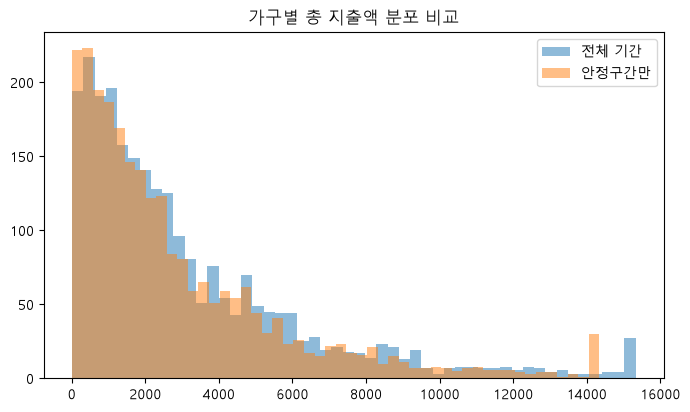


전체기간엔 있지만 안정구간엔 거래가 없는 가구 수: 8


In [8]:
# 전체기간 vs 안정구간 가구별 총지출액 분포 비교
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(hh_total_sales.clip(upper=hh_total_sales.quantile(0.99)), bins=50, alpha=0.5, label="전체 기간")
ax.hist(hh_total_sales_stable.clip(upper=hh_total_sales_stable.quantile(0.99)), bins=50, alpha=0.5, label="안정구간만")
ax.set_title("가구별 총 지출액 분포 비교")
ax.legend()
plt.show()

# 안정구간에 아예 없는 가구가 있는지 (즉, 온보딩/절단 구간에만 존재하던 가구)
hh_all = set(tx["household_key"].unique())
hh_stable = set(tx_stable["household_key"].unique())
print(f"\n전체기간엔 있지만 안정구간엔 거래가 없는 가구 수: {len(hh_all - hh_stable):,}")


## 6. 다음 단계 메모

- 음수/이상치 SALES_VALUE 처리 방침(제거 vs 그대로 사용)을 여기서 확정하고 H4 계산에 일관되게 적용
- 이후 초반구간 길이(N주) 결정 시, 이 노트북의 `tx_stable`(안정구간 필터링된 데이터)을 기준으로 진행
- 가구당 관측치 편차가 크다면, 초반구간을 너무 짧게 잡을 경우 관측치 자체가 없는 가구가 생길 수 있음 — 3번에서 확인한 편차 참고


초반 몇 주를 사용할 지 계산 - 상위지출가구를 뽑기 위함, 후반기데이터가 들어갈 경우 원래 상위였던 가구가 늘어난 것인지, 늘어난 가구를 상위로 정의했는지 모순에 빠짐
관례적으로는 20%이지만 kneed로 곡률탐색

In [10]:
from scipy.stats import spearmanr

# 안정구간 범위 확인 (팀 합의: 17주부터, 상단은 기존 99주 유지)
stable_min_week = tx_stable["WEEK_NO"].min()
stable_max_week = tx_stable["WEEK_NO"].max()
total_stable_weeks = stable_max_week - stable_min_week + 1
print(f"안정구간: {stable_min_week}주 ~ {stable_max_week}주 (총 {total_stable_weeks}주)")

candidate_N = [2, 4, 6, 8, 10, 12, 16, 20]
results = []

for N in candidate_N:
    window = tx_stable[
        (tx_stable["WEEK_NO"] >= stable_min_week) &
        (tx_stable["WEEK_NO"] < stable_min_week + N)
    ].copy()

    # 윈도우 내에서 홀수주/짝수주로 분할 (절대 WEEK_NO 기준이 아니라 윈도우 내 상대 순서 기준)
    window["week_rel"] = window["WEEK_NO"] - stable_min_week
    odd_weeks  = window[window["week_rel"] % 2 == 1]
    even_weeks = window[window["week_rel"] % 2 == 0]

    sales_odd  = odd_weeks.groupby("household_key")["SALES_VALUE"].sum()
    sales_even = even_weeks.groupby("household_key")["SALES_VALUE"].sum()

    # 양쪽 다 존재하는 가구만 비교 (한쪽에만 있으면 순위 비교 불가)
    common_hh = sales_odd.index.intersection(sales_even.index)

    if len(common_hh) < 10:
        results.append({"N": N, "n_households": len(common_hh), "spearman_rho": np.nan})
        continue

    rho, pval = spearmanr(sales_odd.loc[common_hh], sales_even.loc[common_hh])
    results.append({
        "N": N,
        "n_households": len(common_hh),
        "spearman_rho": rho,
        "pct_of_stable_range": round(N / total_stable_weeks * 100, 1),
    })

rank_stability = pd.DataFrame(results)
rank_stability

안정구간: 17주 ~ 99주 (총 83주)


,N,n_households,spearman_rho,pct_of_stable_range
0,2,947,0.404566,2.4
1,4,1397,0.487859,4.8
2,6,1663,0.574319,7.2
3,8,1812,0.640430,9.6
4,10,1913,0.697030,12.0
5,12,1986,0.728662,14.5
6,16,2110,0.780408,19.3
7,20,2188,0.815526,24.1


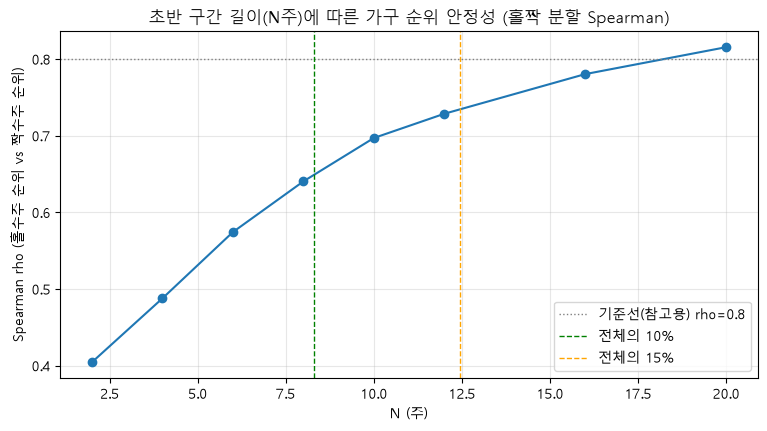

,N,n_households,spearman_rho,pct_of_stable_range
0,2,947,0.404566,2.4
1,4,1397,0.487859,4.8
2,6,1663,0.574319,7.2
3,8,1812,0.640430,9.6
4,10,1913,0.697030,12.0
5,12,1986,0.728662,14.5
6,16,2110,0.780408,19.3
7,20,2188,0.815526,24.1


In [11]:
# 순위 안정성 곡선 시각화
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(rank_stability["N"], rank_stability["spearman_rho"], marker='o')
ax.axhline(0.8, color='gray', linestyle=':', linewidth=1, label='기준선(참고용) rho=0.8')

# 안정구간의 10~15% 상한선 표시
ax.axvline(total_stable_weeks * 0.10, color='green', linestyle='--', linewidth=1, label='전체의 10%')
ax.axvline(total_stable_weeks * 0.15, color='orange', linestyle='--', linewidth=1, label='전체의 15%')

ax.set_title("초반 구간 길이(N주)에 따른 가구 순위 안정성 (홀짝 분할 Spearman)")
ax.set_xlabel("N (주)")
ax.set_ylabel("Spearman rho (홀수주 순위 vs 짝수주 순위)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

rank_stability

In [14]:
!pip install kneed --break-system-packages

In [15]:
# elbow 자동 탐지 (kneed 있으면 사용, 없으면 증가폭 기반 수동 근사)
valid = rank_stability.dropna(subset=["spearman_rho"])

try:
    from kneed import KneeLocator
    kl = KneeLocator(valid["N"], valid["spearman_rho"], curve="concave", direction="increasing")
    print(f"kneed 기준 elbow: N = {kl.knee}주")
except ImportError:
    # 수동: N을 늘렸을 때 rho 증가폭이 가장 급격히 완만해지는 지점
    diffs = valid["spearman_rho"].diff()
    diff_change = diffs.diff()  # 증가폭의 변화율(2차 차분)
    elbow_idx = diff_change.idxmin()  # 증가폭이 가장 급격히 꺾이는 지점
    print(f"(kneed 미설치 - 수동 근사) elbow 후보: N = {valid.loc[elbow_idx, 'N']}주")
    print("정확한 자동 탐지 원하면: pip install kneed --break-system-packages")

print("\n전체 안정구간의 10~15% 상한:", round(total_stable_weeks*0.10,1), "~", round(total_stable_weeks*0.15,1), "주")

kneed 기준 elbow: N = 10주

전체 안정구간의 10~15% 상한: 8.3 ~ 12.4 주


In [13]:
# 최종 N 확정 판단을 돕기 위한 요약 테이블
rank_stability["10~15%_규칙_통과"] = rank_stability["N"] <= total_stable_weeks * 0.15
rank_stability

,N,n_households,spearman_rho,pct_of_stable_range,10~15%_규칙_통과
0,2,947,0.404566,2.4,True
1,4,1397,0.487859,4.8,True
2,6,1663,0.574319,7.2,True
3,8,1812,0.640430,9.6,True
4,10,1913,0.697030,12.0,True
5,12,1986,0.728662,14.5,True
6,16,2110,0.780408,19.3,False
7,20,2188,0.815526,24.1,False


파레토 곡선(상위 X%결정)

In [16]:
# N=10주 기준 가구별 지출액 (초반 구간)
early_window = tx_stable[
    (tx_stable["WEEK_NO"] >= stable_min_week) &
    (tx_stable["WEEK_NO"] < stable_min_week + 10)
].copy()

hh_early_sales = early_window.groupby("household_key")["SALES_VALUE"].sum().sort_values(ascending=False)

print(f"초반 10주 기준 가구 수: {len(hh_early_sales):,}")
print(hh_early_sales.describe())

초반 10주 기준 가구 수: 2,272
count    2272.000000
mean      356.284177
std       393.754770
min         0.790000
25%        91.047500
50%       227.540000
75%       479.062500
max      3700.550000
Name: SALES_VALUE, dtype: float64


In [17]:
# 파레토(로렌츠) 곡선 계산
sorted_sales = hh_early_sales.sort_values(ascending=False).values
n = len(sorted_sales)

cum_pct_households = np.arange(1, n + 1) / n * 100
cum_pct_sales = np.cumsum(sorted_sales) / sorted_sales.sum() * 100

lorenz_df = pd.DataFrame({
    "cum_pct_households": cum_pct_households,
    "cum_pct_sales": cum_pct_sales,
})

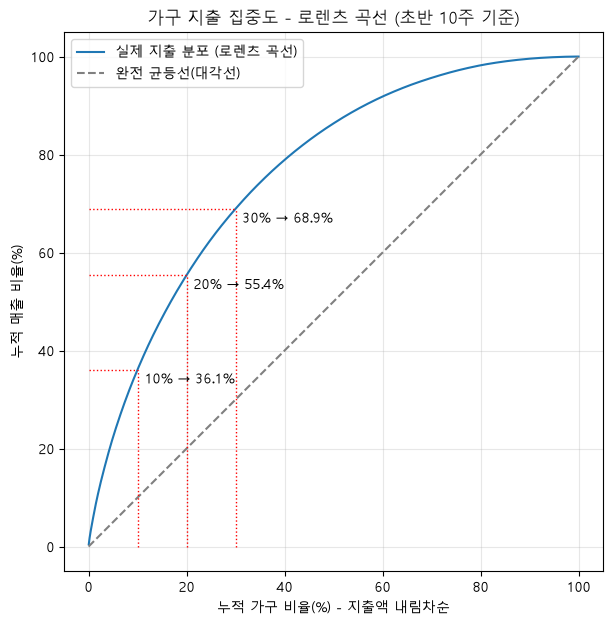

In [18]:
# 로렌츠 곡선 시각화
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(cum_pct_households, cum_pct_sales, label="실제 지출 분포 (로렌츠 곡선)")
ax.plot([0, 100], [0, 100], linestyle='--', color='gray', label="완전 균등선(대각선)")

for x_ref in [10, 20, 30]:
    y_ref = np.interp(x_ref, cum_pct_households, cum_pct_sales)
    ax.plot([x_ref, x_ref], [0, y_ref], color='red', linestyle=':', linewidth=1)
    ax.plot([0, x_ref], [y_ref, y_ref], color='red', linestyle=':', linewidth=1)
    ax.annotate(f"{x_ref}% → {y_ref:.1f}%", (x_ref, y_ref), textcoords="offset points", xytext=(5, -10))

ax.set_title("가구 지출 집중도 - 로렌츠 곡선 (초반 10주 기준)")
ax.set_xlabel("누적 가구 비율(%) - 지출액 내림차순")
ax.set_ylabel("누적 매출 비율(%)")
ax.legend()
ax.grid(alpha=0.3)
ax.set_aspect('equal')
plt.show()

In [20]:
# Gini 계수 계산 (numpy 버전 호환)
trapezoid_fn = getattr(np, "trapezoid", None) or np.trapz

gini = 1 - 2 * trapezoid_fn(cum_pct_sales / 100, cum_pct_households / 100)
print(f"Gini 계수: {gini:.3f} (0=완전균등, 1=완전독점)")

Gini 계수: -0.532 (0=완전균등, 1=완전독점)


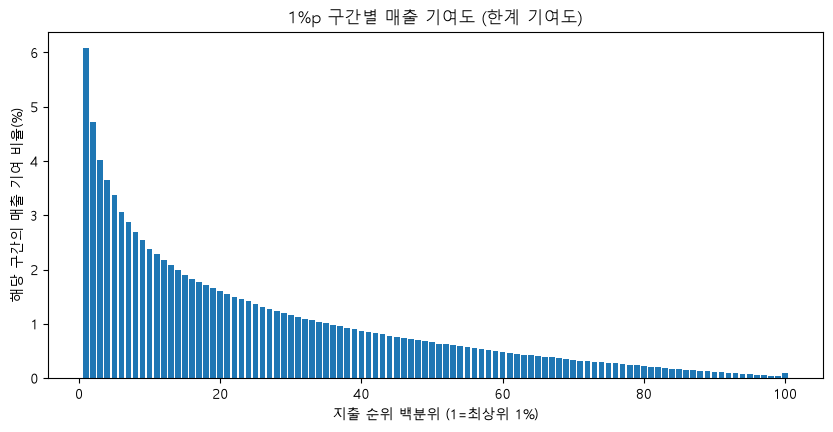

,percentile,bucket_sales,bucket_pct_of_total
0,1,49223.68,6.080919
1,2,38169.39,4.715311
2,3,32470.61,4.011304
3,4,29511.33,3.645725
4,5,27244.65,3.365708
5,6,24820.58,3.066246
6,7,23237.85,2.870722
7,8,21779.78,2.690597
8,9,20565.20,2.540552
9,10,19231.34,2.375772


In [21]:
# 한계 기여도(marginal contribution) 계산 - 1%p 구간마다 매출 기여도
bucket_size_households = max(1, n // 100)  # 가구를 100개 구간(1%씩)으로 분할

marginal = []
for i in range(100):
    start = i * bucket_size_households
    end = (i + 1) * bucket_size_households if i < 99 else n
    bucket_sales = sorted_sales[start:end].sum()
    marginal.append({
        "percentile": i + 1,
        "bucket_sales": bucket_sales,
        "bucket_pct_of_total": bucket_sales / sorted_sales.sum() * 100,
    })

marginal_df = pd.DataFrame(marginal)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(marginal_df["percentile"], marginal_df["bucket_pct_of_total"])
ax.set_title("1%p 구간별 매출 기여도 (한계 기여도)")
ax.set_xlabel("지출 순위 백분위 (1=최상위 1%)")
ax.set_ylabel("해당 구간의 매출 기여 비율(%)")
plt.show()

marginal_df.head(30)

In [22]:
# elbow 자동 탐지 (한계 기여도가 평평해지는 지점)
try:
    from kneed import KneeLocator
    kl = KneeLocator(marginal_df["percentile"], marginal_df["bucket_pct_of_total"],
                      curve="convex", direction="decreasing")
    print(f"kneed 기준 elbow: 상위 {kl.knee}%")
except ImportError:
    pct_change = -marginal_df["bucket_pct_of_total"].diff() / marginal_df["bucket_pct_of_total"].shift(1) * 100
    print("(kneed 미설치) 구간별 기여도 감소율:")
    print(pct_change.head(30))

kneed 기준 elbow: 상위 18%


In [23]:
# 후보 X 값들 민감도 표 - 관습적 20%와 실제 데이터 기반 후보 비교
candidate_X = [5, 10, 15, 20, 25, 30]
rows = []
for x in candidate_X:
    y = np.interp(x, cum_pct_households, cum_pct_sales)
    rows.append({
        "상위 X%": x,
        "해당 그룹의 매출 기여 비율(%)": round(y, 1),
        "매출 집중도 (기여%/가구%)": round(y / x, 2),
    })

sensitivity_table = pd.DataFrame(rows)
sensitivity_table

,상위 X%,해당 그룹의 매출 기여 비율(%),매출 집중도 (기여%/가구%)
0,5,22.3,4.47
1,10,36.1,3.61
2,15,46.7,3.11
3,20,55.4,2.77
4,25,62.7,2.51
5,30,68.9,2.30
